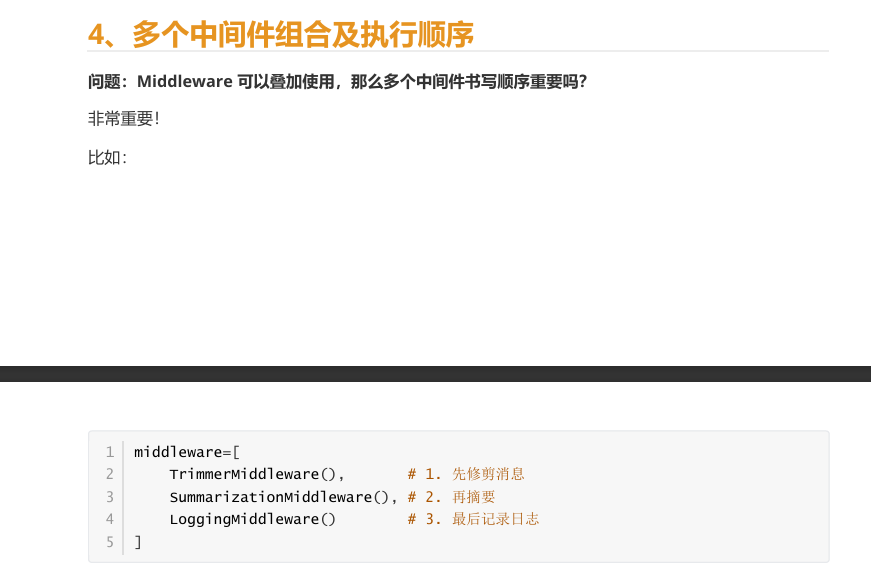

举例：
1. 代码

In [1]:
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent
from dotenv import load_dotenv
import os

from langchain_core.messages import AIMessageChunk
from rprint import rprint

load_dotenv(override=True)
DEEPSEEK_API_KEY = os.getenv("DEEPSEEK_API_KEY")
DEEPSEEK_BASE_URL = "https://api.deepseek.com"
model = init_chat_model(
    model="deepseek:deepseek-v4-flash",
    api_key=DEEPSEEK_API_KEY,
    extra_body={"thinking": {"type": "disabled"}},  #关闭思考模式
)


In [2]:
from langchain.agents.middleware import AgentMiddleware


class Middleware1(AgentMiddleware):
    def before_model(self, state, runtime):
        print("[中间件1] before_model")
        return None

    def after_model(self, state, runtime):
        print("[中间件1] after_model")
        return None


class Middleware2(AgentMiddleware):
    def before_model(self, state, runtime):
        print("[中间件2] before_model")
        return None

    def after_model(self, state, runtime):
        print("[中间件2] after_model")
        return None


class Middleware3(AgentMiddleware):
    def before_model(self, state, runtime):
        print("[中间件3] before_model")
        return None

    def after_model(self, state, runtime):
        print("[中间件3] after_model")
        return None


agent = create_agent(
    model=model,
    tools=[],
    middleware=[Middleware1(), Middleware2(), Middleware3()]
)
print("\n执行一次调用，观察顺序：")
agent.invoke({"messages": [{"role": "user", "content": "测试"}]})
print("\n关键点：")
print("  - before_model: 正序执行（1→2→3）")
print("  - after_model: 逆序执行（3→2→1）")
print("  - 类似洋葱模型：1→2→3→模型→3→2→1")


执行一次调用，观察顺序：
[中间件1] before_model
[中间件2] before_model
[中间件3] before_model
[中间件3] after_model
[中间件2] after_model
[中间件1] after_model

关键点：
  - before_model: 正序执行（1→2→3）
  - after_model: 逆序执行（3→2→1）
  - 类似洋葱模型：1→2→3→模型→3→2→1
